In [2]:
import numpy as np 
import pandas as pd 
import re 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline 

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']   = 10

Đọc dữ liệu đầu vào 

In [29]:
df = pd.read_csv('D:\Việt Anh\\MachineLearning\\ml_project_final\\data\\data\\train.csv', low_memory = False)
print(df.shape)
df.head(5)

(100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


XỬ LÝ DỮ LIỆU RÁC VÀ FILL

In [30]:
df.drop(columns = ['ID', 'Name', "SSN"], inplace = True, errors = 'ignore')


In [31]:
def clean_numeric(series):
    """Xóa ký tự lỗi, chuyển về float, đặt âm/vô lý thành NaN."""
    s = series.astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
    s = pd.to_numeric(s, errors="coerce")
    return s

NUMERIC_COLS = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Loan",
    "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Num_Credit_Inquiries", "Outstanding_Debt", "Credit_Utilization_Ratio",
    "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance",
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

# Các giá trị âm vô lý → NaN
NON_NEGATIVE = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Num_of_Loan", "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries", "Outstanding_Debt", "Total_EMI_per_month",
    "Amount_invested_monthly",
]
for col in NON_NEGATIVE:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

In [32]:
VALID_VALUES = {
    "Credit_Mix": {"Bad", "Standard", "Good"},

    "Occupation": {
        "Scientist", "Teacher", "Engineer", "Entrepreneur",
        "Developer", "Lawyer", "Media_Manager", "Doctor",
        "Journalist", "Manager", "Accountant", "Musician",
        "Mechanic", "Writer", "Architect",
    },

    "Payment_Behaviour" : {
        "High_spent_Small_value_payments",
        "Low_spent_Large_value_payments",
        "Low_spent_Medium_value_payments",
        "Low_spent_Small_value_payments",
        "High_spent_Large_value_payments",
        "High_spent_Medium_value_payments",
    },
}

print("Số NaN mới sinh ra sau khi lọc:")
for col, valid_set in VALID_VALUES.items():
    if col not in df.columns:
        continue

    before_nan   = df[col].isna().sum()
    before_dirty = (~df[col].isin(valid_set) & df[col].notna()).sum()

    # Thay giá trị không hợp lệ → NaN
    df[col] = df[col].where(df[col].isin(valid_set), other=np.nan)

    after_nan = df[col].isna().sum()
    print(f"  {col:<16} | giá trị lỗi: {before_dirty:>5} "
          f"| NaN trước: {before_nan:>5} → NaN sau: {after_nan:>5}")

Số NaN mới sinh ra sau khi lọc:
  Credit_Mix       | giá trị lỗi: 20195 | NaN trước:     0 → NaN sau: 20195
  Occupation       | giá trị lỗi:  7062 | NaN trước:     0 → NaN sau:  7062
  Payment_Behaviour | giá trị lỗi:  7600 | NaN trước:     0 → NaN sau:  7600


In [33]:
missing_value = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_value, 'Percentage (%)': missing_percent})
print(missing_data[missing_data['Missing Values']> 0])

print(f"\n So luong dong trung lap: {df.duplicated().sum()}")

                         Missing Values  Percentage (%)
Age                                 886           0.886
Occupation                         7062           7.062
Monthly_Inhand_Salary             15002          15.002
Num_Bank_Accounts                    21           0.021
Num_of_Loan                        3876           3.876
Type_of_Loan                      11408          11.408
Num_of_Delayed_Payment             7646           7.646
Changed_Credit_Limit               2091           2.091
Num_Credit_Inquiries               1965           1.965
Credit_Mix                        20195          20.195
Credit_History_Age                 9030           9.030
Amount_invested_monthly            4479           4.479
Payment_Behaviour                  7600           7.600
Monthly_Balance                    1200           1.200

 So luong dong trung lap: 0


In [34]:
def parse_credit_history_age(val):
    """'22 Years and 3 Months' → 267 (tháng)"""
    if pd.isna(val):
        return np.nan
    val = str(val)
    years  = re.search(r"(\d+)\s*Year",  val, re.IGNORECASE)
    months = re.search(r"(\d+)\s*Month", val, re.IGNORECASE)
    y = int(years.group(1))  if years  else 0
    m = int(months.group(1)) if months else 0
    return y * 12 + m

import re
df["Credit_History_Age"] = df["Credit_History_Age"].apply(parse_credit_history_age)

In [35]:
def iqr_clip(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - factor * IQR, upper=Q3 + factor * IQR)

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = iqr_clip(df[col])

In [ ]:
# SKEWED_COLS = [
#     "Annual_Income",
#     "Monthly_Inhand_Salary",
#     "Outstanding_Debt",
#     "Amount_invested_monthly",
#     "Total_EMI_per_month",   
# ]

# DOMAIN_CLIP_COLS = {
#     "Num_Bank_Accounts":      (0, 10),   # > 10 tài khoản là bất thường
#     "Num_of_Loan":            (0, 9),    # > 9 khoản vay đồng thời rất hiếm
#     "Num_of_Delayed_Payment": (0, 30),   # > 30 lần trễ = cực đoan
#     "Num_Credit_Inquiries":   (0, 20),   # > 20 lần tra cứu = cực đoan
#     "Delay_from_due_date":    (0, 60),   # trễ > 60 ngày thường là bad debt
#     "Num_Credit_Card":        (0, 11),   # > 11 thẻ tín dụng rất hiếm
# }
# PERCENTILE_ONLY_COLS = [
#     "Age",
#     "Interest_Rate",
#     "Changed_Credit_Limit",
#     "Credit_Utilization_Ratio",
#     "Monthly_Balance",          # giữ giá trị âm (hợp lý tài chính)
# ]

# def percentile_clip(series, lower_pct=0.01, upper_pct=0.99):
#     """
#     Clip tại percentile thay vì IQR.
#     Chỉ loại bỏ 1% cực đoan mỗi đầu → mass point rất nhỏ (~1% mẫu).
#     So với IQR factor=3.0: IQR có thể clip 5-15% mẫu tùy phân phối.
#     """
#     lo = series.quantile(lower_pct)
#     hi = series.quantile(upper_pct)
#     return series.clip(lower=lo, upper=hi)


# def percentile_clip_then_log(series, lower_pct=0.01, upper_pct=0.99):
#     """
#     Bước 1: Percentile clip → loại cực đoan thực sự
#     Bước 2: log1p → nén phần đuôi còn lại, không tạo mass point
#     Thứ tự quan trọng: clip TRƯỚC, log SAU
#     (nếu log trước rồi clip → clip trên log scale ít có ý nghĩa)
#     """
#     clipped = percentile_clip(series, lower_pct, upper_pct)
#     return np.log1p(clipped)


# for col in SKEWED_COLS:
#     if col == "Total_EMI_per_month":
#         continue  # xử lý riêng bên dưới
#     if col in df.columns:
#         before_max = df[col].max()
#         df[col] = percentile_clip_then_log(df[col])

# # --- Nhóm 2: Count/Discrete ---
# for col, (lo, hi) in DOMAIN_CLIP_COLS.items():
#     if col in df.columns:
#         before_max = df[col].max()
#         df[col] = df[col].clip(lower=lo, upper=hi)

# # --- Nhóm 3: Continuous thông thường ---
# for col in PERCENTILE_ONLY_COLS:
#     if col in df.columns:
#         before_range = f"[{df[col].min():.1f}, {df[col].max():.1f}]"
#         df[col] = percentile_clip(df[col])


In [ ]:
import pandas as pd
import numpy as np

# 0. Tiền xử lý Type_of_Loan trước (cột đặc biệt - multi-value)
# Type_of_Loan chứa nhiều loại loan trong 1 cell, ví dụ:
# "Auto Loan, Credit-Builder Loan, Personal Loan"
# → cần xử lý riêng, không impute thô như categorical thông thường

def get_loan_mode_per_customer(df):
    """
    Với mỗi customer, tìm chuỗi Type_of_Loan xuất hiện nhiều nhất
    trong 8 tháng (trong số các tháng không bị NaN).
    """
    def mode_or_nan(x):
        valid = x.dropna()
        if len(valid) == 0:
            return np.nan
        return valid.mode()[0]

    return df.groupby("Customer_ID")["Type_of_Loan"].transform(mode_or_nan)



# 1. Imputation cho các cột số
NUMERIC_IMPUTE_COLS = [
    "Age",
    "Num_Bank_Accounts",
    "Num_of_Loan",
    "Changed_Credit_Limit",
    "Monthly_Inhand_Salary",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Credit_History_Age",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

def impute_numeric_by_customer(df, cols):
    """
    Điền NaN bằng median của chính Customer_ID đó.
    Không cần global fallback vì không có customer nào thiếu 8/8.
    """
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue

        before = df[col].isna().sum()

        df[col] = df.groupby("Customer_ID")[col].transform(
            lambda x: x.fillna(x.median())
        )

        after = df[col].isna().sum()
        print(f"  {col:<28} | filled: {before - after:>5} | còn lại: {after:>4}")

    return df


# 2. Imputation cho Type_of_Loan (categorical + global fallback)
def impute_type_of_loan(df):
    """
    Bước 1: Điền bằng mode của chính customer đó (các tháng có giá trị).
    Bước 2: 1426 customers thiếu 8/8 → điền bằng global mode.
    """
    df = df.copy()
    before = df["Type_of_Loan"].isna().sum()

    # Bước 1: customer-level mode
    df["Type_of_Loan"] = get_loan_mode_per_customer(df)

    # Bước 2: global fallback cho 1426 customers thiếu 8/8
    global_mode = df["Type_of_Loan"].mode()[0]
    remaining   = df["Type_of_Loan"].isna().sum()
    df["Type_of_Loan"] = df["Type_of_Loan"].fillna(global_mode)

    filled_customer = before - remaining
    filled_global   = remaining

    print(f"  {'Type_of_Loan':<28} | "
          f"customer-fill: {filled_customer:>5} | "
          f"global-fill: {filled_global:>5} (global_mode='{global_mode}')")

    return df


# 3. Chạy toàn bộ pipeline imputation
def run_imputation(df):
    print(">>> BẮT ĐẦU IMPUTATION\n")

    print("[1] Numeric — customer median:")
    df = impute_numeric_by_customer(df, NUMERIC_IMPUTE_COLS)

    print("\n[2] Categorical — customer mode + global fallback:")
    df = impute_type_of_loan(df)

    # Kiểm tra tổng kết
    remaining_missing = df[NUMERIC_IMPUTE_COLS + ["Type_of_Loan"]].isna().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]

    print("\n>>> KẾT QUẢ SAU IMPUTATION:")
    if len(remaining_missing) == 0:
        print("  không còn missing value trong các cột đã xử lý.")
    else:
        print(remaining_missing)

    return df

df = run_imputation(df)

>>> BẮT ĐẦU IMPUTATION

[1] Numeric — customer median:
  Age                          | filled:   886 | còn lại:    0
  Num_Bank_Accounts            | filled:    21 | còn lại:    0
  Num_of_Loan                  | filled:  3876 | còn lại:    0
  Changed_Credit_Limit         | filled:  2091 | còn lại:    0
  Monthly_Inhand_Salary        | filled: 15002 | còn lại:    0
  Num_of_Delayed_Payment       | filled:  7646 | còn lại:    0
  Num_Credit_Inquiries         | filled:  1965 | còn lại:    0
  Credit_History_Age           | filled:  9030 | còn lại:    0
  Amount_invested_monthly      | filled:  4479 | còn lại:    0
  Monthly_Balance              | filled:  1200 | còn lại:    0

[2] Categorical — customer mode + global fallback:
  Type_of_Loan                 | customer-fill:     0 | global-fill: 11408 (global_mode='Not Specified')

>>> KẾT QUẢ SAU IMPUTATION:
  ✅ Không còn missing value trong các cột đã xử lý.


In [37]:
def impute_categorical_by_customer(df, cols):
    """
    Bước 1: mode của chính Customer_ID đó.
    Bước 2: global mode fallback nếu customer thiếu 8/8.
    """
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue

        before = df[col].isna().sum()

        # Bước 1: customer-level mode
        def fill_mode(x):
            valid = x.dropna()
            if len(valid) == 0:
                return x           # toàn NaN → để fallback xử lý
            return x.fillna(valid.mode()[0])

        df[col] = df.groupby("Customer_ID")[col].transform(fill_mode)

        # Bước 2: global mode fallback
        after_step1   = df[col].isna().sum()
        global_mode   = df[col].mode()[0]
        df[col]       = df[col].fillna(global_mode)
        after_step2   = df[col].isna().sum()

        cust_filled   = before - after_step1
        global_filled = after_step1 - after_step2

        note = f" | ⚠ global fallback: {global_filled} (mode='{global_mode}')" \
               if global_filled > 0 else ""
        print(f"  {col:<16} filled: {cust_filled:>5} (customer){note} "
              f"| còn lại: {after_step2}")

    return df


print("Imputing Occupation & Credit_Mix:")
df = impute_categorical_by_customer(df, list(VALID_VALUES.keys()))

Imputing Occupation & Credit_Mix:
  Credit_Mix       filled: 20195 (customer) | còn lại: 0
  Occupation       filled:  7062 (customer) | còn lại: 0
  Payment_Behaviour filled:  7600 (customer) | còn lại: 0


In [14]:
missing_value = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_value, 'Percentage (%)': missing_percent})
print(missing_data[missing_data['Missing Values']> 0])

print(f"\n So luong dong trung lap: {df.duplicated().sum()}")

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

 So luong dong trung lap: 0


Encoding


In [38]:
df_enc = df.drop(columns=['Month'], errors='ignore').copy()
print(df_enc.shape)

(100000, 24)


In [39]:
#encode credit_score 
credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2} 
df_enc['Credit_Score'] = df_enc['Credit_Score'].map(credit_score_map) 
print("Phan phoi credit_score")
print(df_enc["Credit_Score"].value_counts().sort_index().rename({0:'Poor', 1:'Standard', 2:'Good'}))

Phan phoi credit_score
Credit_Score
Poor        28998
Standard    53174
Good        17828
Name: count, dtype: int64


In [40]:
#encode credit_mix 
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df_enc['Credit_Mix'] = df_enc['Credit_Mix'].map(credit_mix_map)

In [41]:
# Encode Payment_of_Min_Amount (Ordinal)
pom_map = {'No': 0, 'NM': 1, 'Yes': 2}
df_enc['Payment_of_Min_Amount'] = df_enc['Payment_of_Min_Amount'].map(pom_map)

unmapped = df_enc['Payment_of_Min_Amount'].isna().sum()
print(f"NaN sau map: {unmapped}")

NaN sau map: 0


Trước khi encode Payment_Behaviour thì ta cần hiểu đặc tính của cột này như sau : 
- Cấu trúc: "{Spend_Level}_spent_{Value_Level}_value_payments"
  Ví dụ:    "High_spent_Small_value_payments"
=> tách thay vì OHE : 
- vì OHE tạo ra 6 cột nhị phân, mất đi cấu trúc 2 chiều độc lập; trong khi tách thì tạo ra 2 cột ordinal, giảm từ 6 xuống 2 và linear model có thể học coefficient riêng cho từng chiều 

=>  
 Spend_Level:  Low=0, High=1
 Value_Level:  Small=0, Medium=1, Large=2

In [42]:
print(df_enc.shape)

(100000, 24)


In [43]:
df_enc['Spend_Level'] = (
    df_enc['Payment_Behaviour']
    .str.extract(r'^(High|Low)_spent', expand=False)
    .map({'Low': 0, 'High': 1})
)
df_enc['Value_Level'] = (
    df_enc['Payment_Behaviour']
    .str.extract(r'(Small|Medium|Large)_value', expand=False)
    .map({'Small': 0, 'Medium': 1, 'Large': 2})
)

df_enc.drop(columns=['Payment_Behaviour'], inplace=True)
print("NaN check:", df_enc[['Spend_Level', 'Value_Level']].isna().sum().to_dict())


NaN check: {'Spend_Level': 0, 'Value_Level': 0}


Mỗi cell chứa nhiều loại loan: "Auto Loan, Personal Loan, and Student Loan"
Multi-hot = một cột binary cho mỗi loại loan.

In [44]:
def multihot_type_of_loan(df, col='Type_of_Loan'):
    cleaned = df[col].str.replace(r'\band\b', '', regex=True)
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True).str.strip()
    loan_lists = cleaned.str.split(r'\s*,\s*')

    all_types = set()
    loan_lists.dropna().apply(
        lambda x: all_types.update([t.strip() for t in x if t.strip()])
    )
    all_types = sorted(all_types)

    print(f"Các loại loan ({len(all_types)}):")
    for t in all_types:
        cnt = loan_lists.apply(lambda x: t in x if isinstance(x, list) else False).sum()
        print(f"  {t:<35} | n={cnt}")

    for loan_type in all_types:
        col_name = 'Loan_' + loan_type.replace(' ', '_').replace('-', '_')
        df[col_name] = loan_lists.apply(
            lambda x: 1 if (isinstance(x, list) and loan_type in x) else 0
        )

    df.drop(columns=[col], inplace=True)
    return df

df_enc = multihot_type_of_loan(df_enc)
loan_cols = [c for c in df_enc.columns if c.startswith('Loan_')]
print(f"\nSố cột Loan_: {len(loan_cols)}")

Các loại loan (9):
  Auto Loan                           | n=30560
  Credit-Builder Loan                 | n=31728
  Debt Consolidation Loan             | n=31040
  Home Equity Loan                    | n=31400
  Mortgage Loan                       | n=31360
  Not Specified                       | n=43088
  Payday Loan                         | n=31944
  Personal Loan                       | n=31104
  Student Loan                        | n=31040

Số cột Loan_: 9


Occupation là NOMINAL (không có thứ tự) với ~16 giá trị.
OHE được dùng THỐNG NHẤT cho tất cả model trong guide này vì:
 - Naive Bayes, LR, MLP, KNN, SVM đều là distance/probability-based  
 - Label Encoding tạo thứ tự giả tạo gây hại cho những model này
 - drop_first=True: loại 1 cột → tránh dummy variable trap (multicollinearity hoàn hảo)    
 -đặc biệt quan trọng với Logistic Regression

In [45]:
occ_dummies = pd.get_dummies(df_enc['Occupation'], prefix='Occ', drop_first=True)
df_enc = pd.concat([df_enc.drop(columns=['Occupation']), occ_dummies], axis=1)

occ_cols = [c for c in df_enc.columns if c.startswith('Occ_')]
print(f"Số cột Occ_ được tạo: {len(occ_cols)}")
print(f"Shape tổng sau toàn bộ encoding: {df_enc.shape}")

Số cột Occ_ được tạo: 14
Shape tổng sau toàn bộ encoding: (100000, 46)


In [46]:
df_enc.head(5)

,Customer_ID,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occ_Entrepreneur,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Writer
0,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3,7.0,...,False,False,False,False,False,False,False,True,False,False
1,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,-1,6.5,...,False,False,False,False,False,False,False,True,False,False
2,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3,7.0,...,False,False,False,False,False,False,False,True,False,False
3,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,5,4.0,...,False,False,False,False,False,False,False,True,False,False
4,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,6,6.5,...,False,False,False,False,False,False,False,True,False,False


VISUALIZATION 

Phân phối các cột oridinal/binary da encode

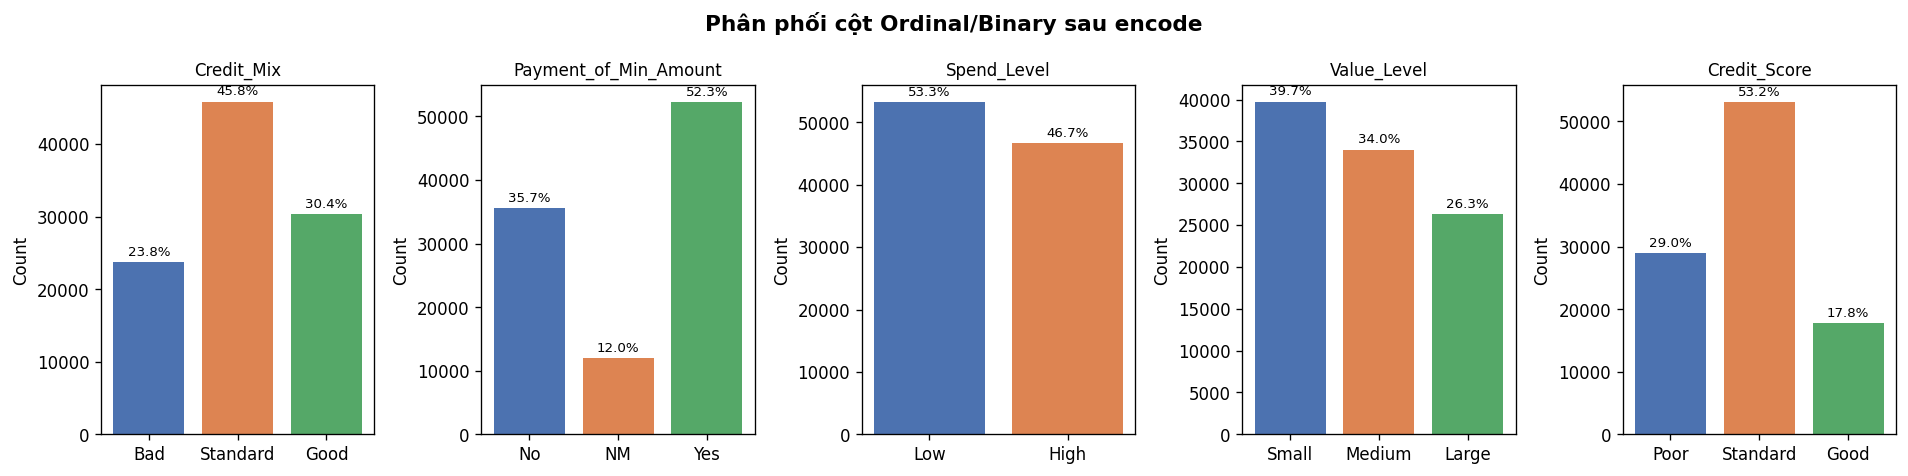

In [47]:
ordinal_cols = ['Credit_Mix', 'Payment_of_Min_Amount', 'Spend_Level', 'Value_Level', 'Credit_Score']

fig, axes = plt.subplots(1, len(ordinal_cols), figsize=(16, 4))
fig.suptitle('Phân phối cột Ordinal/Binary sau encode', fontsize=13, fontweight='bold')

label_maps = {
    'Credit_Mix':             {0:'Bad', 1:'Standard', 2:'Good'},
    'Payment_of_Min_Amount':  {0:'No',  1:'NM',       2:'Yes'},
    'Spend_Level':            {0:'Low', 1:'High'},
    'Value_Level':            {0:'Small', 1:'Medium',  2:'Large'},
    'Credit_Score':           {0:'Poor', 1:'Standard', 2:'Good'},
}

for ax, col in zip(axes, ordinal_cols):
    counts = df_enc[col].value_counts().sort_index()
    labels = [label_maps[col].get(k, str(k)) for k in counts.index]
    bars   = ax.bar(labels, counts.values, color=['#4C72B0','#DD8452','#55A868'][:len(counts)])
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{val/total:.1%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('01_ordinal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

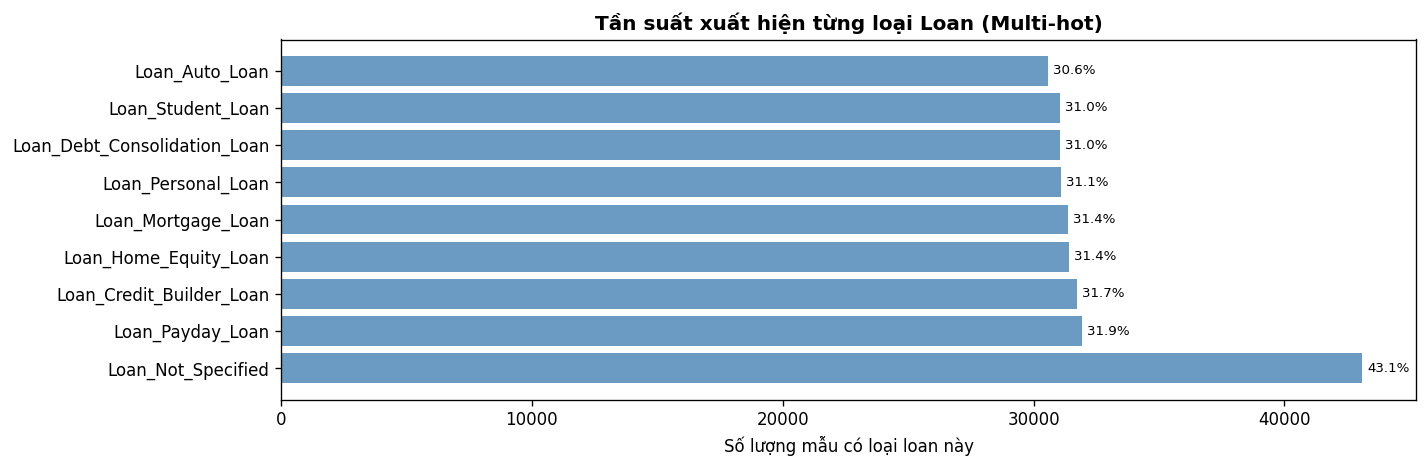

Tất cả loại loan đủ phổ biến.


In [48]:
fig, ax = plt.subplots(figsize=(12, 4))
loan_counts = df_enc[loan_cols].sum().sort_values(ascending=False)
bars = ax.barh(loan_counts.index, loan_counts.values, color='steelblue', alpha=0.8)
ax.set_xlabel('Số lượng mẫu có loại loan này')
ax.set_title('Tần suất xuất hiện từng loại Loan (Multi-hot)', fontweight='bold')

total = len(df_enc)
for bar, val in zip(bars, loan_counts.values):
    ax.text(val + total*0.002, bar.get_y() + bar.get_height()/2,
            f'{val/total:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('02_loan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

LOAN_THRESHOLD = 0.01  
rare_loans = loan_counts[loan_counts / total < LOAN_THRESHOLD].index.tolist()
if rare_loans:
    print(f" Loại loan hiếm (< 1%), sẽ DROP: {rare_loans}")
    df_enc.drop(columns=rare_loans, inplace=True)
    loan_cols = [c for c in df_enc.columns if c.startswith('Loan_')]
    print(f"Còn lại {len(loan_cols)} cột Loan_")
else:
    print("Tất cả loại loan đủ phổ biến.")

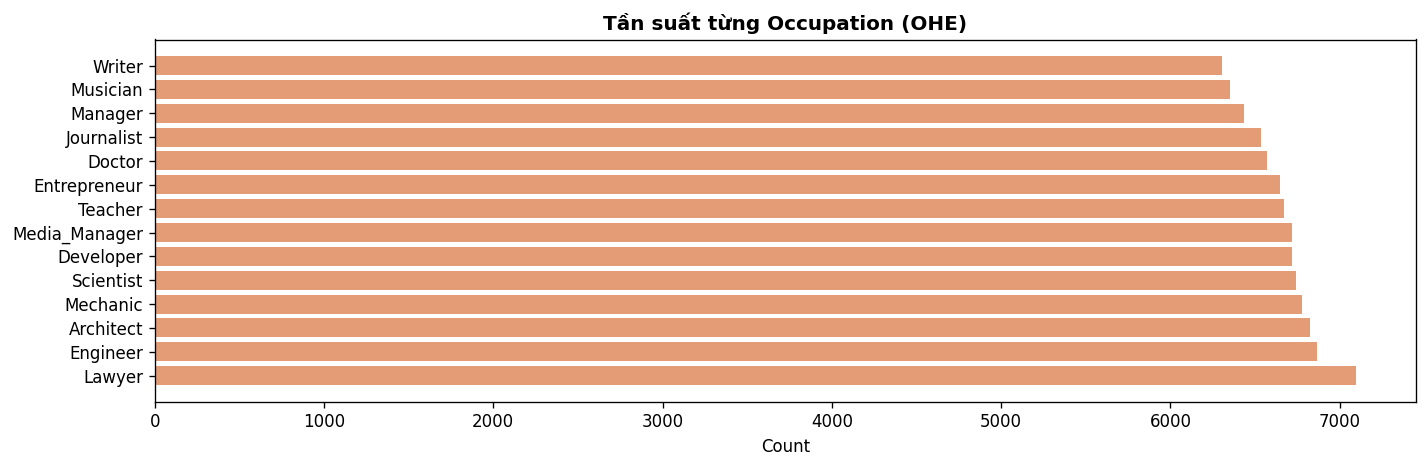

In [49]:
fig, ax = plt.subplots(figsize=(12, 4))
occ_counts = df_enc[occ_cols].sum().sort_values(ascending=False)
ax.barh(occ_counts.index.str.replace('Occ_', ''), occ_counts.values,
        color='#DD8452', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Tần suất từng Occupation (OHE)', fontweight='bold')
plt.tight_layout()
plt.savefig('03_occupation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

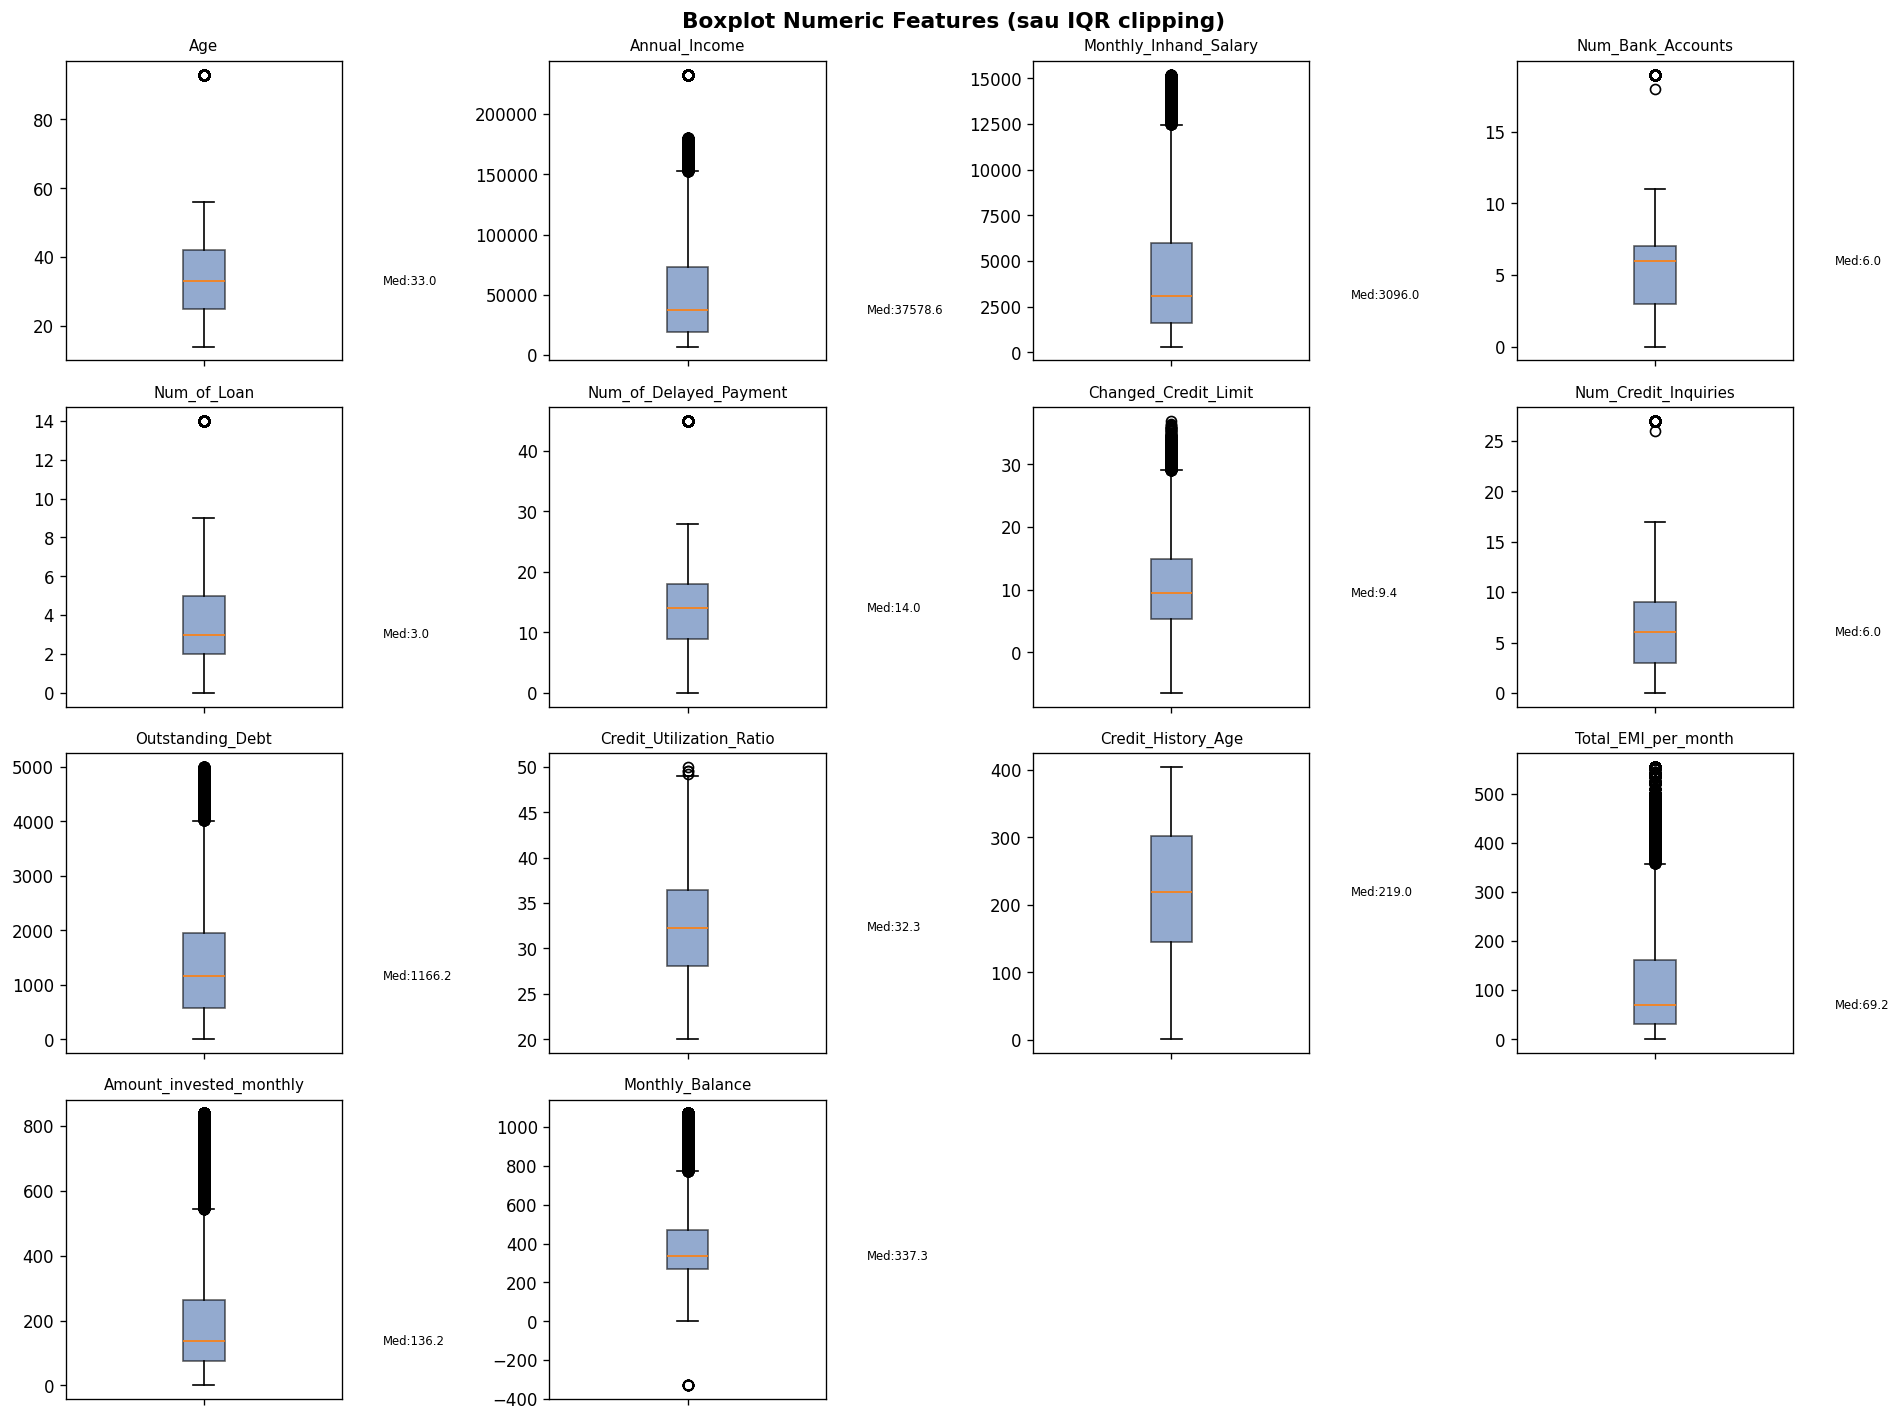

In [50]:
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]
numeric_cols = [c for c in numeric_cols if c in df_enc.columns]

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_enc[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticklabels([])

    # Annotate statistics
    q1, median, q3 = df_enc[col].quantile([0.25, 0.5, 0.75])
    axes[i].text(1.15, median, f'Med:{median:.1f}', fontsize=7,
                 va='center', transform=axes[i].get_yaxis_transform())

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Numeric Features (sau IQR clipping)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Nhìn vào ta có thể thấy đc: 
1. nhóm lệch phải nặng 
- Annual_Income; Monthly_Inhand_Salary; Total_EMI_per_month; Amount_invested_monthly; Outstanding_Debt 
=> phân phối lệch phải nặng ảnh hưởng đến Logistic, MLP, Naive Bayes và làm cho PCA bị domiant bởi các feature có variance lớn 
===> dùng log1p cho dữ liệu lệch phải nặng 

2. nhóm outliers đơn lẻ còn xót 
- age, num_bank_accounts, num_of_loan, num_of_delayed_payment, num_credit_inquiries 
===> clip thêm các cột count với ngưỡng hợp lý về mặt domain 

3. changed_credit_limit - phân phối bất thường 
   monthly_balance - có giá trị âm 
    credit_utilization_ratio - range quá hẹp, chỉ nằm trong 20- 50 

xử lý các lỗi vừa gặp phải 

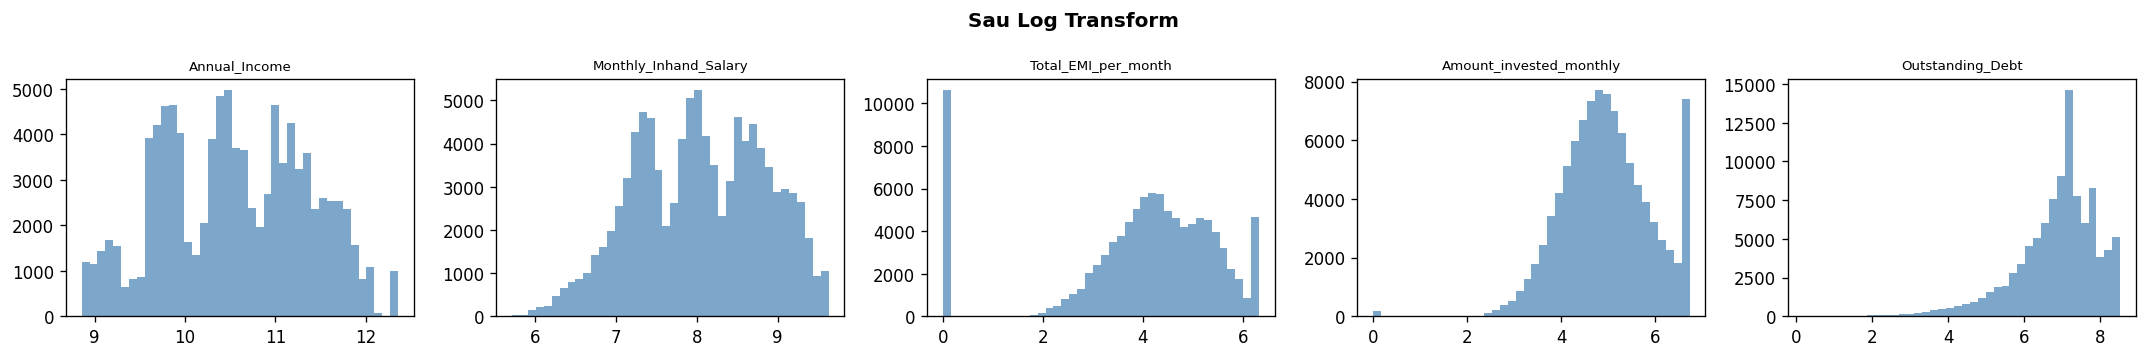

In [51]:
# log transform cho right-skewed 
log_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary',
    'Total_EMI_per_month', 'Amount_invested_monthly',
    'Outstanding_Debt'
]

for col in log_cols:
    df_enc[col] = np.log1p(df_enc[col])

# Kiểm tra lại sau transform
fig, axes = plt.subplots(1, len(log_cols), figsize=(18, 3))
for ax, col in zip(axes, log_cols):
    ax.hist(df_enc[col].dropna(), bins=40, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=8)
plt.suptitle('Sau Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

**** nhận xét: 
+) annual_income, monthly_inhand_salary đã đỡ lệch phải hơn trước nhưng  nhận ra 1 điều đó là dữ liệu nhiều đỉnh => nguyên nhân có thể là do dữ liệu thật sự có nhóm phân khúc thu nhập (low, mid, high income) 
=> ảnh hưởng tới các model như naive bayes, logistic, svm 
   không ảnh hưởng hoặc ảnh hưởng ít tới: MLP, KNN
   

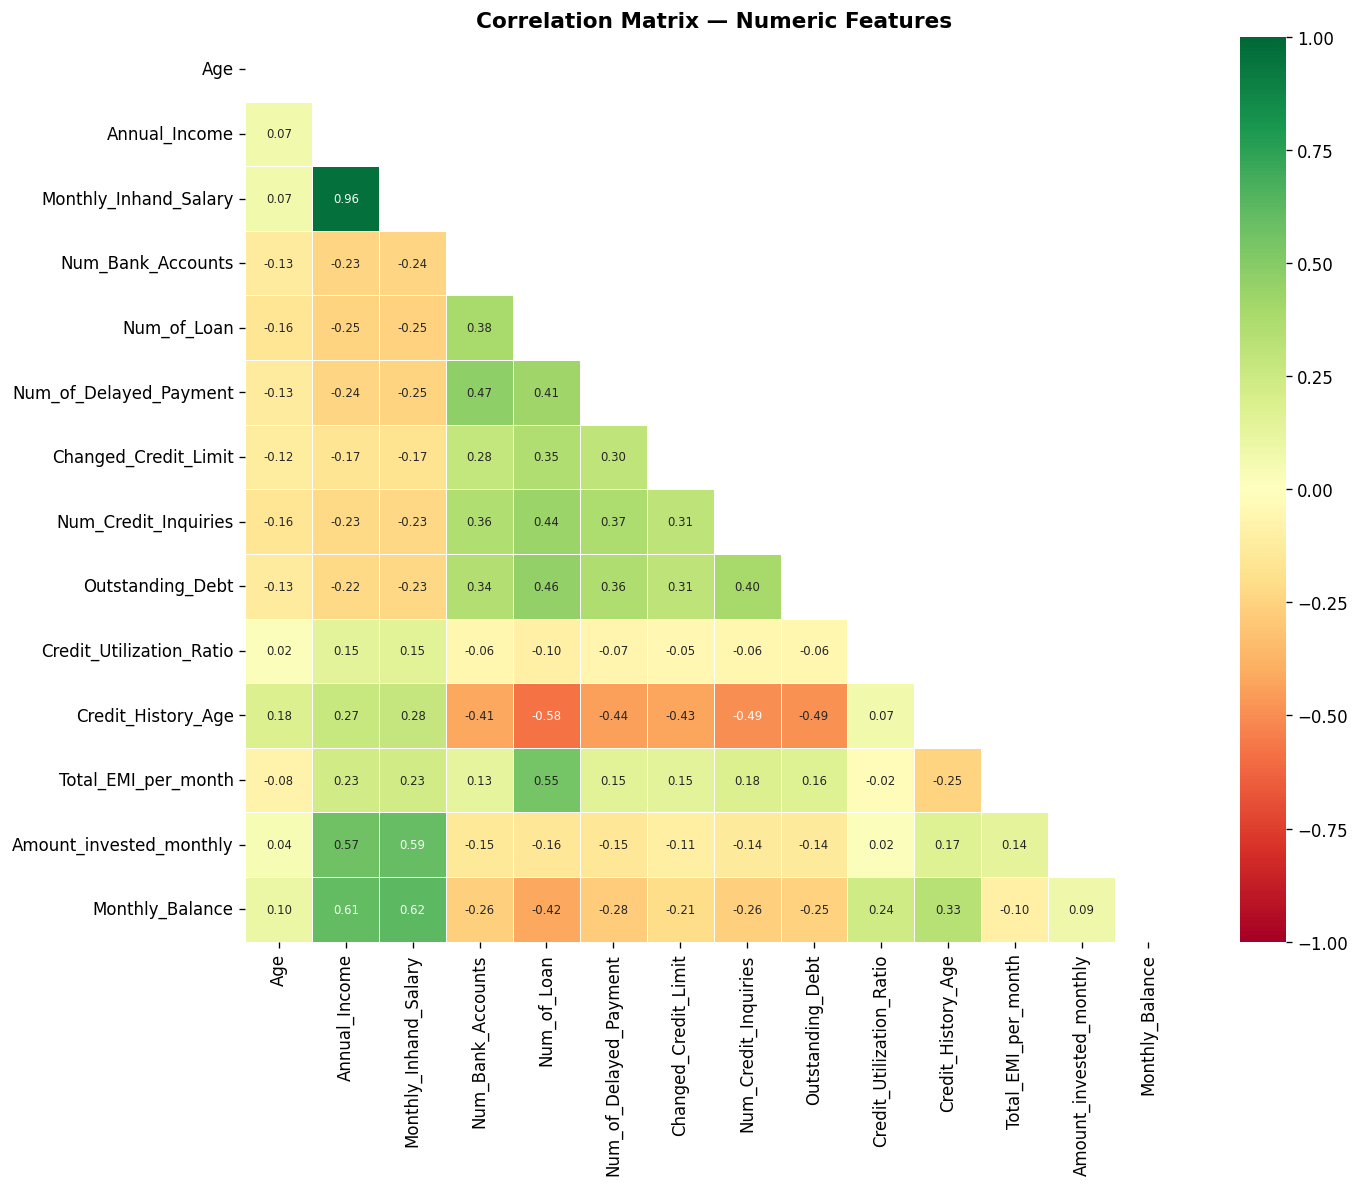

In [ ]:
corr_matrix = df_enc[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Annual_Income và Monthly_Salary_Inhand tương quan cao => nên xóa 1 cột đi

In [54]:
df_enc.drop(columns=['Annual_Income'], inplace=True)

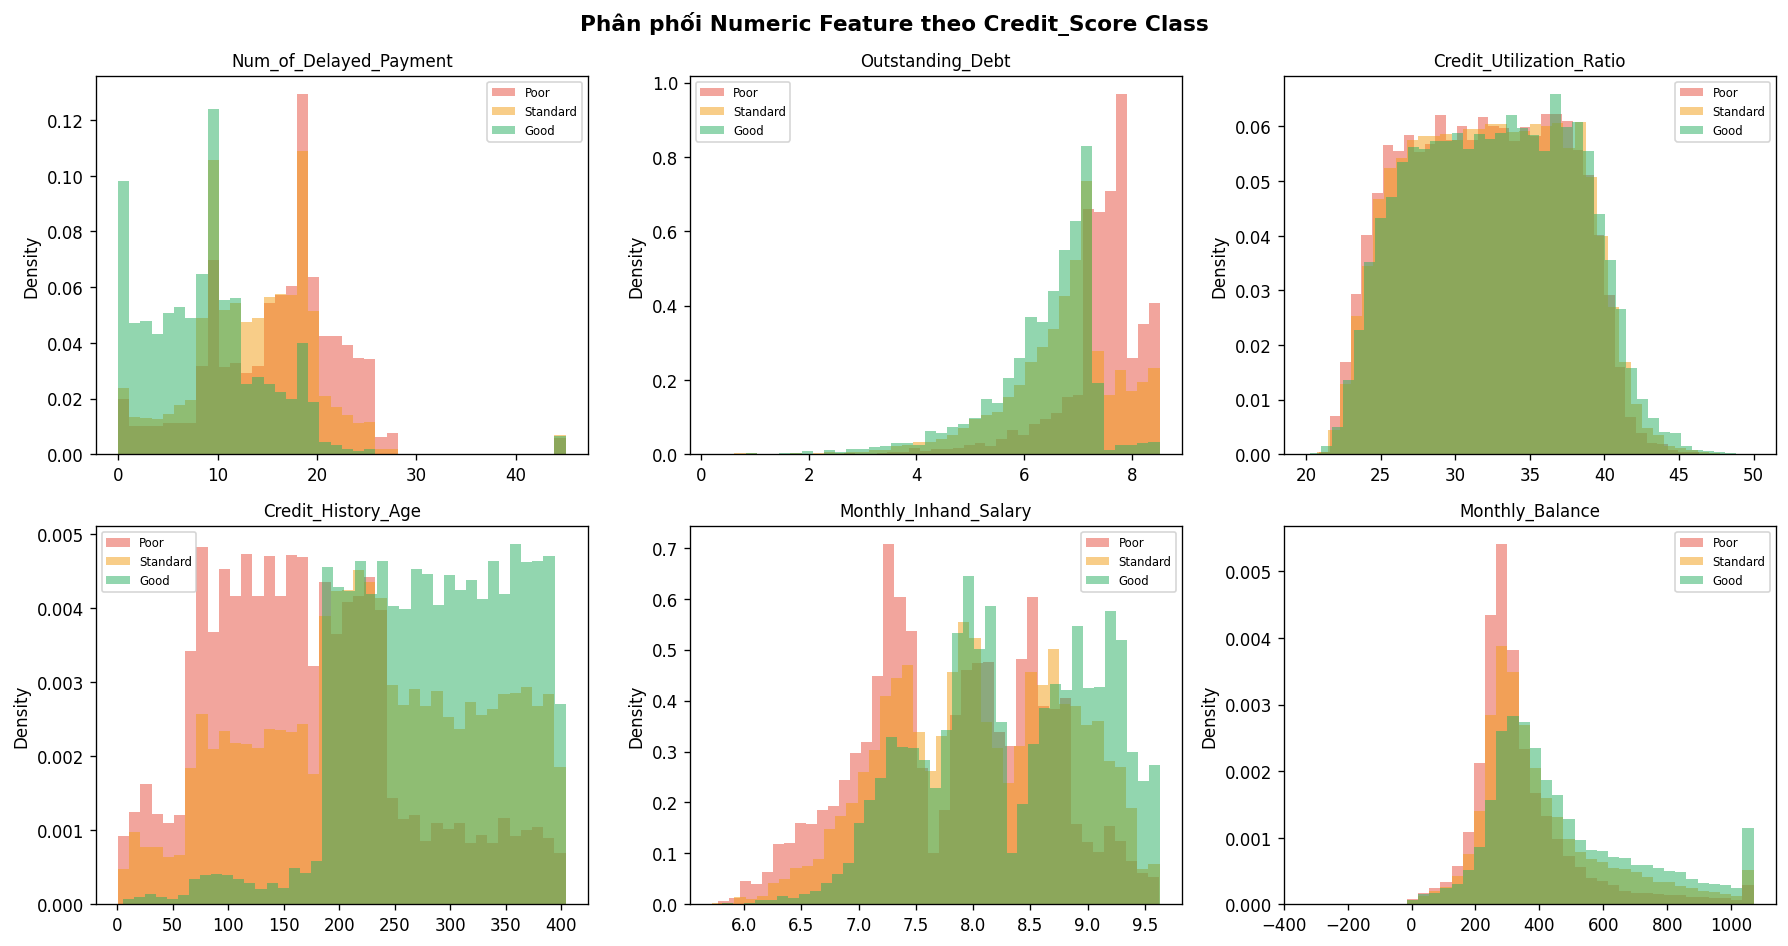

In [ ]:
key_features = ['Num_of_Delayed_Payment', 'Outstanding_Debt',
                'Credit_Utilization_Ratio', 'Credit_History_Age',
                'Monthly_Inhand_Salary', 'Monthly_Balance']
key_features = [f for f in key_features if f in df_enc.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}  # Poor=đỏ, Standard=vàng, Good=xanh

for i, feat in enumerate(key_features):
    for cls in [0, 1, 2]:
        subset = df_enc[df_enc['Credit_Score'] == cls][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5,
                     color=colors[cls],
                     label={0:'Poor', 1:'Standard', 2:'Good'}[cls],
                     density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

fig.suptitle('Phân phối Numeric Feature theo Credit_Score Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
feature_cols = [c for c in df_enc.columns if c not in ['Credit_Score', 'Customer_ID']]
X_all = df_enc[feature_cols] 
y_all = df_enc['Credit_Score'] 
groups = df_enc["Customer_ID"] 

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42) 
train_idx, test_idx = next(gss.split(X_all, y_all, groups))
X_train = X_all.iloc[train_idx].reset_index(drop=True)
X_test  = X_all.iloc[test_idx].reset_index(drop=True)
y_train = y_all.iloc[train_idx].reset_index(drop=True)
y_test  = y_all.iloc[test_idx].reset_index(drop=True)

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

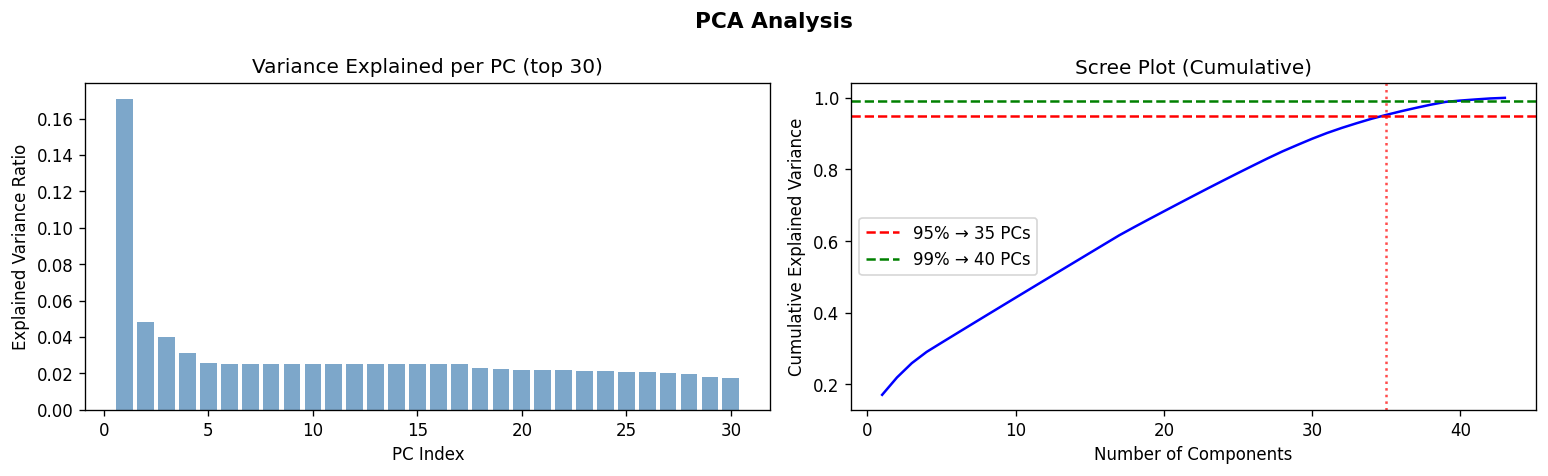

PCA: 35 components → 95% variance | 40 components → 99% variance
Giảm từ 43 → 35 features (giữ 95% thông tin)


In [ ]:
pca_analysis = PCA(random_state=42)
pca_analysis.fit(X_train_scaled)

cumvar = np.cumsum(pca_analysis.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 31), pca_analysis.explained_variance_ratio_[:30],
            color='steelblue', alpha=0.7)
axes[0].set_xlabel('PC Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained per PC (top 30)')

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=1.5)
axes[1].axhline(0.95, color='r',  linestyle='--', label=f'95% → {n_95} PCs')
axes[1].axhline(0.99, color='g',  linestyle='--', label=f'99% → {n_99} PCs')
axes[1].axvline(n_95, color='r',  linestyle=':',  alpha=0.7)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Scree Plot (Cumulative)')
axes[1].legend()

fig.suptitle('PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

PCA: 35 components → 95% variance | 40 components → 99% variance
Giảm từ 43 → 35 features (giữ 95% thông tin)

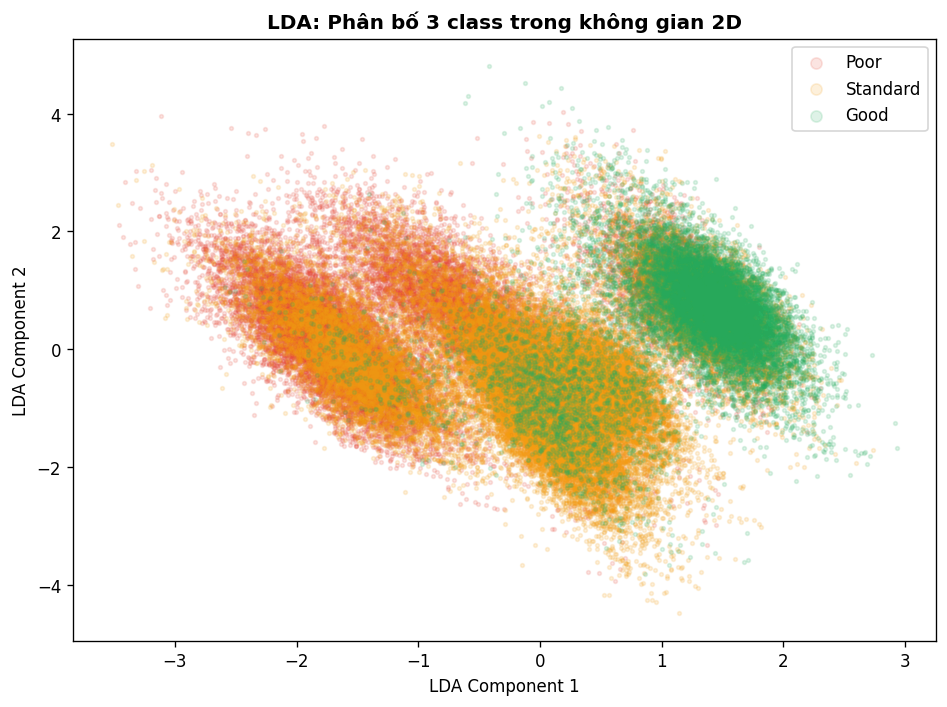

In [64]:
lda_analysis = LDA()
X_train_lda2 = lda_analysis.fit_transform(X_train_scaled, y_train)
X_test_lda2  = lda_analysis.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}
labels_map  = {0: 'Poor', 1: 'Standard', 2: 'Good'}

for cls in [0, 1, 2]:
    mask = y_train == cls
    ax.scatter(X_train_lda2[mask, 0], X_train_lda2[mask, 1],
               c=colors_map[cls], label=labels_map[cls],
               alpha=0.15, s=5)

ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
ax.set_title('LDA: Phân bố 3 class trong không gian 2D', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('08_lda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    """Train, predict, và in đầy đủ report."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n{'='*58}")
    print(f"  {name}")
    print(f"{'='*58}")
    print(classification_report(
        y_te, y_pred,
        target_names=['Poor (0)', 'Standard (1)', 'Good (2)'],
        digits=4
    ))

    return model

In [ ]:
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

N_KNN = min(20, n_95)
pca_knn = PCA(n_components=N_KNN, random_state=42)
X_train_pca_knn = pca_knn.fit_transform(X_train_scaled)
X_test_pca_knn  = pca_knn.transform(X_test_scaled)

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  
    activation='relu',           
    solver='adam',               
    alpha=0.001,            
    batch_size=256,             
    learning_rate='adaptive',     
    max_iter=200,
    early_stopping=True,         
    validation_fraction=0.1,    
    n_iter_no_change=15,         
    random_state=42,
    verbose=False
)
evaluate_model(mlp_model, X_train_pca, X_test_pca, y_train, y_test,
               "MLP + PCA")


  MLP + PCA
              precision    recall  f1-score   support

    Poor (0)     0.6032    0.6362    0.6193      5726
Standard (1)     0.6740    0.6992    0.6864     10580
    Good (2)     0.5471    0.4421    0.4890      3694

    accuracy                         0.6337     20000
   macro avg     0.6081    0.5925    0.5982     20000
weighted avg     0.6303    0.6337    0.6307     20000



MLPClassifier(alpha=0.001, batch_size=256, early_stopping=True,
              hidden_layer_sizes=(128, 64), learning_rate='adaptive',
              n_iter_no_change=15, random_state=42)

In [73]:
k = 31  

knn_model = KNeighborsClassifier(
    n_neighbors=k,
    metric='euclidean',
    weights='distance',   
    n_jobs=-1
)
evaluate_model(knn_model, X_train_pca_knn, X_test_pca_knn, y_train, y_test,
               "KNN + PCA(20D)")



  KNN + PCA(20D)
              precision    recall  f1-score   support

    Poor (0)     0.6095    0.5756    0.5921      5726
Standard (1)     0.6553    0.7154    0.6840     10580
    Good (2)     0.5316    0.4377    0.4801      3694

    accuracy                         0.6241     20000
   macro avg     0.5988    0.5763    0.5854     20000
weighted avg     0.6193    0.6241    0.6200     20000



KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=31,
                     weights='distance')